# Exploratory data analysis

In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown
from src.data_loader import load_partition, predictors, fingerprints
def report(name):
    display(Markdown((ROOT / 'reports' / name).read_text(encoding='utf-8')))
def figure(name):
    display(Image(filename=str(ROOT / 'figures' / name)))


In [2]:
train=pd.read_csv(ROOT/'data/processed/train.csv')
display(train.describe(include='all'))

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
count,80648.000000,80648.000000,80648,80648,80648,80648.000000,80648.000000,8.064800e+04,8.064800e+04,8.064800e+04,80648.000000,80648.000000,8.064800e+04,8.064800e+04,80648.000000,80648.000000,80648.000000,80648.000000,8.064800e+04,80648.000000,80648.000000,8.064800e+04,8.064800e+04,80648.000000,80648.000000,80648.000000,80648.000000,80648.000000,80648.000000,80648.000000,8.064800e+04,80648.000000,80648.000000,80648.000000,80648.000000,80648.000000,80648.000000,80648.000000,80648.000000,80648.000000,80648.000000,80648.000000,80648.00000,80648,80648.000000
unique,NaN,NaN,132,13,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN
top,NaN,NaN,tcp,-,FIN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,NaN
freq,NaN,NaN,60850,46510,59408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41328,NaN
mean,63377.825997,1.269989,NaN,NaN,NaN,31.632564,32.013652,1.440448e+04,2.527703e+04,2.862720e+04,135.926768,129.632266,4.244773e+07,1.161890e+06,8.351974,11.722337,462.848865,112.805360,5.748728e+03,856.072720,192.387313,1.611077e+09,1.605718e+09,190.869693,0.067190,0.034132,0.033058,174.817776,208.276002,0.177897,3.690556e+03,5.100102,0.796102,3.128447,1.960830,1.392868,3.923086,0.018748,0.018748,0.191499,3.872012,4.770819,0.00553,NaN,0.487551
std,44512.850041,4.960878,NaN,NaN,NaN,175.915056,143.030831,2.255913e+05,1.874738e+05,1.014184e+05,107.329417,115.406469,2.101978e+08,3.100683e+06,85.169284,68.688941,4616.907279,1131.742879,4.165803e+04,4702.934874,109.748352,1.421631e+09,1.419141e+09,110.635257,0.091865,0.051321,0.046881,254.030140,309.189762,1.110656,6.922307e+04,6.419264,0.841847,4.124719,3.430368,2.123917,6.256221,0.138081,0.138081,0.586345,4.971673,6.341803,0.07416,NaN,0.499848
min,1.000000,0.000000,NaN,NaN,NaN,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,28.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.00000,NaN,0.000000
25%,25642.500000,0.005370,NaN,NaN,NaN,6.000000,4.000000,5.360000e+02,2.680000e+02,2.562399e+01,31.000000,29.000000,8.914756e+03,2.773880e+03,1.000000,0.000000,0.411329,0.248608,1.205226e+01,0.375192,255.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,58.000000,44.000000,0.000000,0.000000e+00,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.00000,NaN,0.000000
50%,53874.000000,0.374293,NaN,NaN,NaN,10.000000,8.000000,9.940000e+02,6.420000e+02,7.629641e+01,62.000000,29.000000,5.342275e+04,9.585108e+03,2.000000,2.000000,23.792254,22.344623,1.411704e+03,73.493043,255.000000,1.433795e+09,1.418260e+09,255.000000,0.000790,0.000624,0.000155,79.000000,80.000000,0.000000,0.000000e+00,3.000000,1.000000,2.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,2.000000,3.000000,0.00000,NaN,0.000000
75%,97740.250000,1.004549,NaN,NaN,NaN,22.000000,20.000000,2.843750e+03,3.380000e+03,2.973241e+03,254.000000,252.000000,7.484764e+05,6.212914e+05,6.000000,7.000000,77.310291,86.371728,4.506672e+03,196.021903,255.000000,2.868728e+09,2.861041e+09,255.000000,0.128223,0.065746,0.059888,132.00000

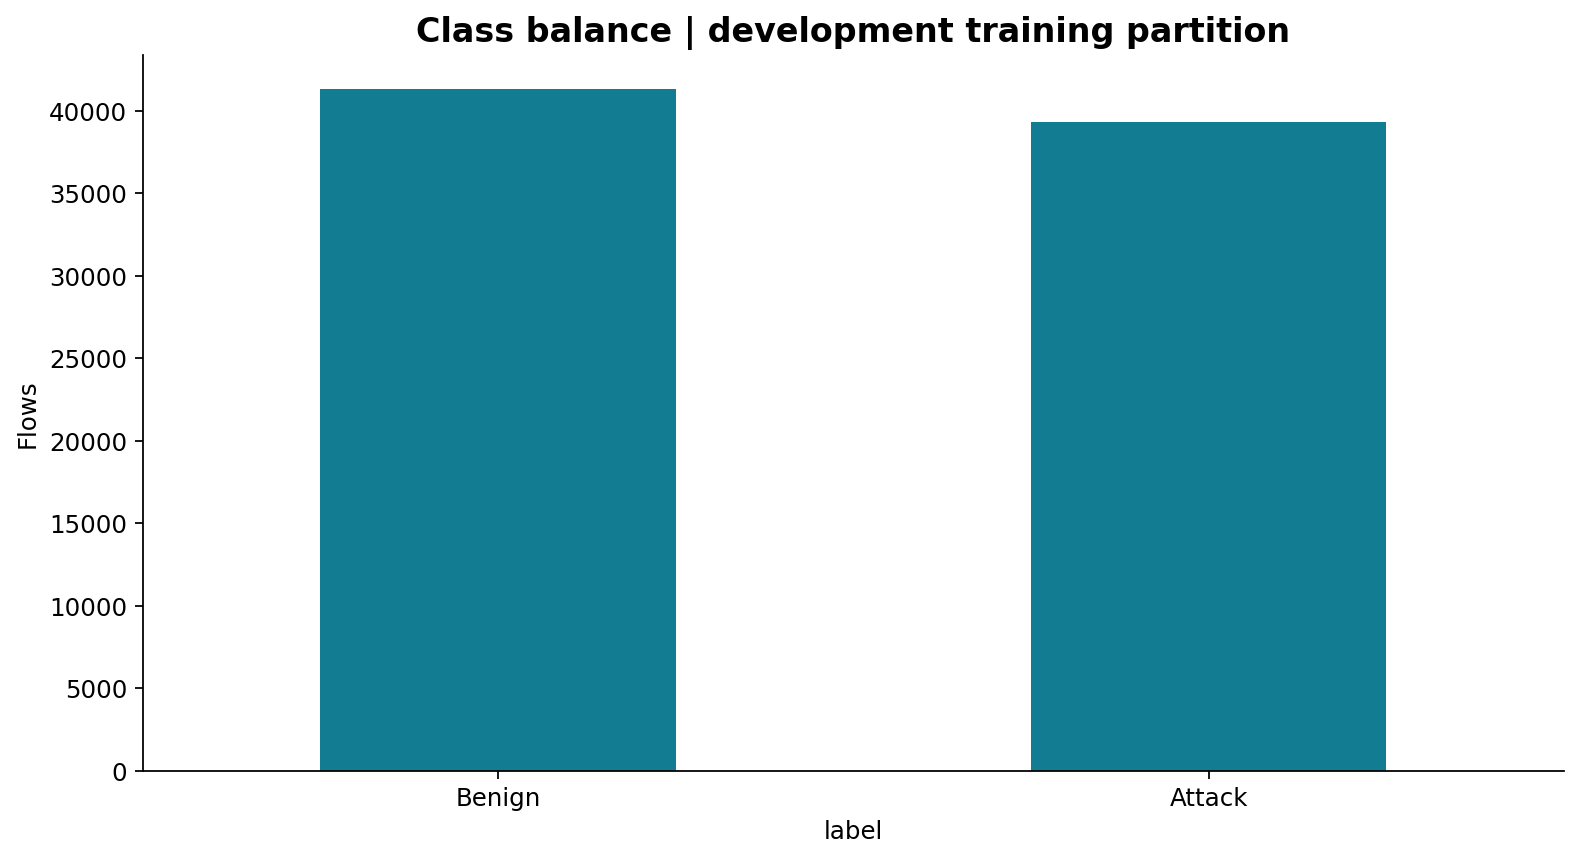

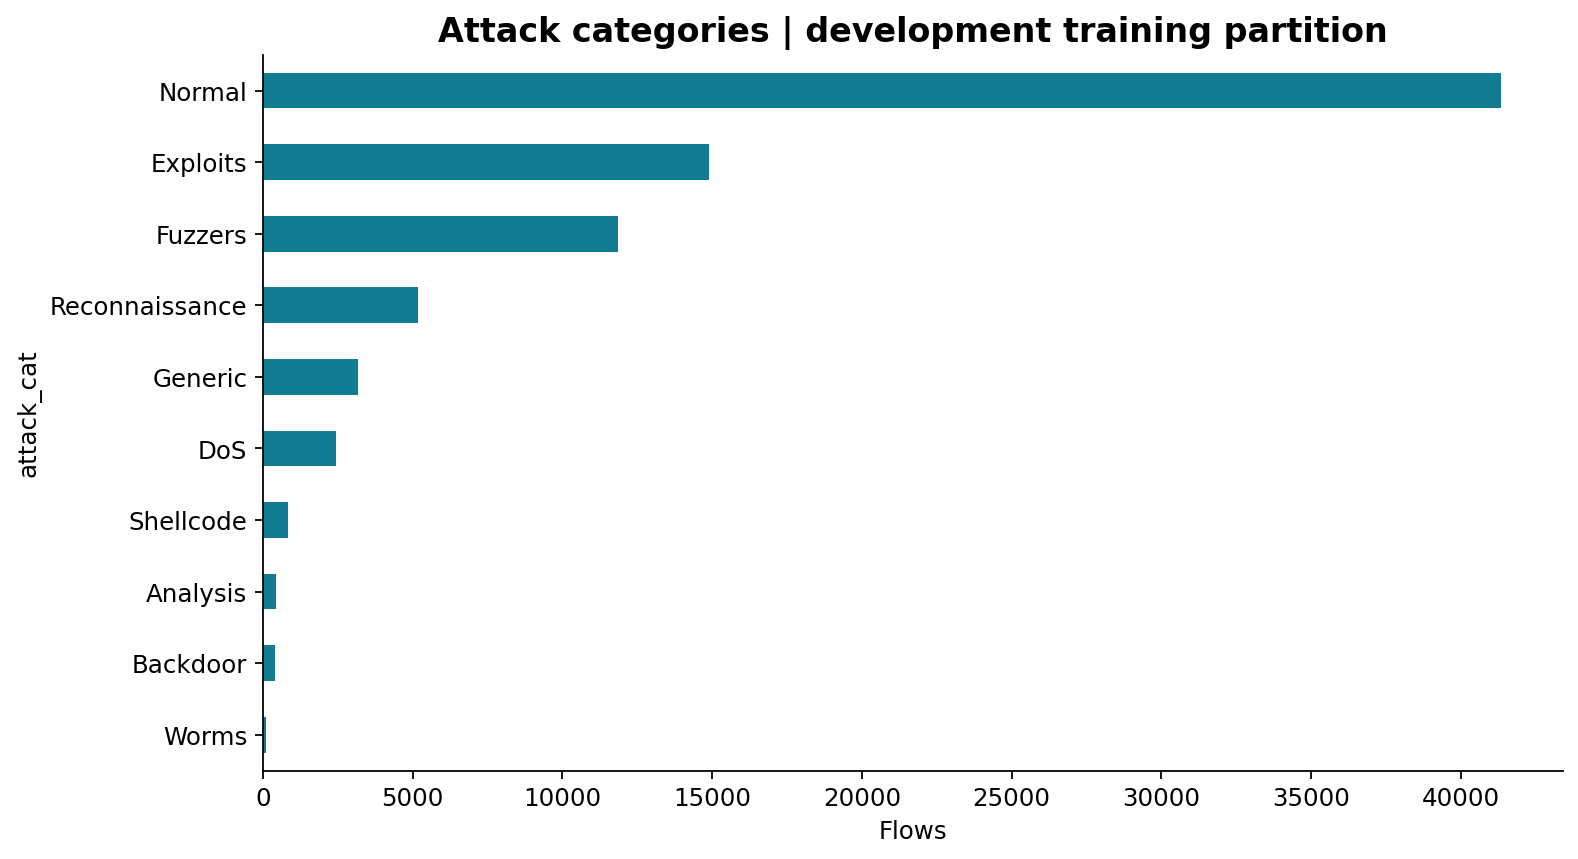

In [3]:
figure('class_distribution.png')
figure('attack_categories.png')

Interpretation: class and category counts reveal representation. Overall binary performance cannot establish rare-attack coverage. Weighting is compared during tuning; no synthetic oversampling is applied.

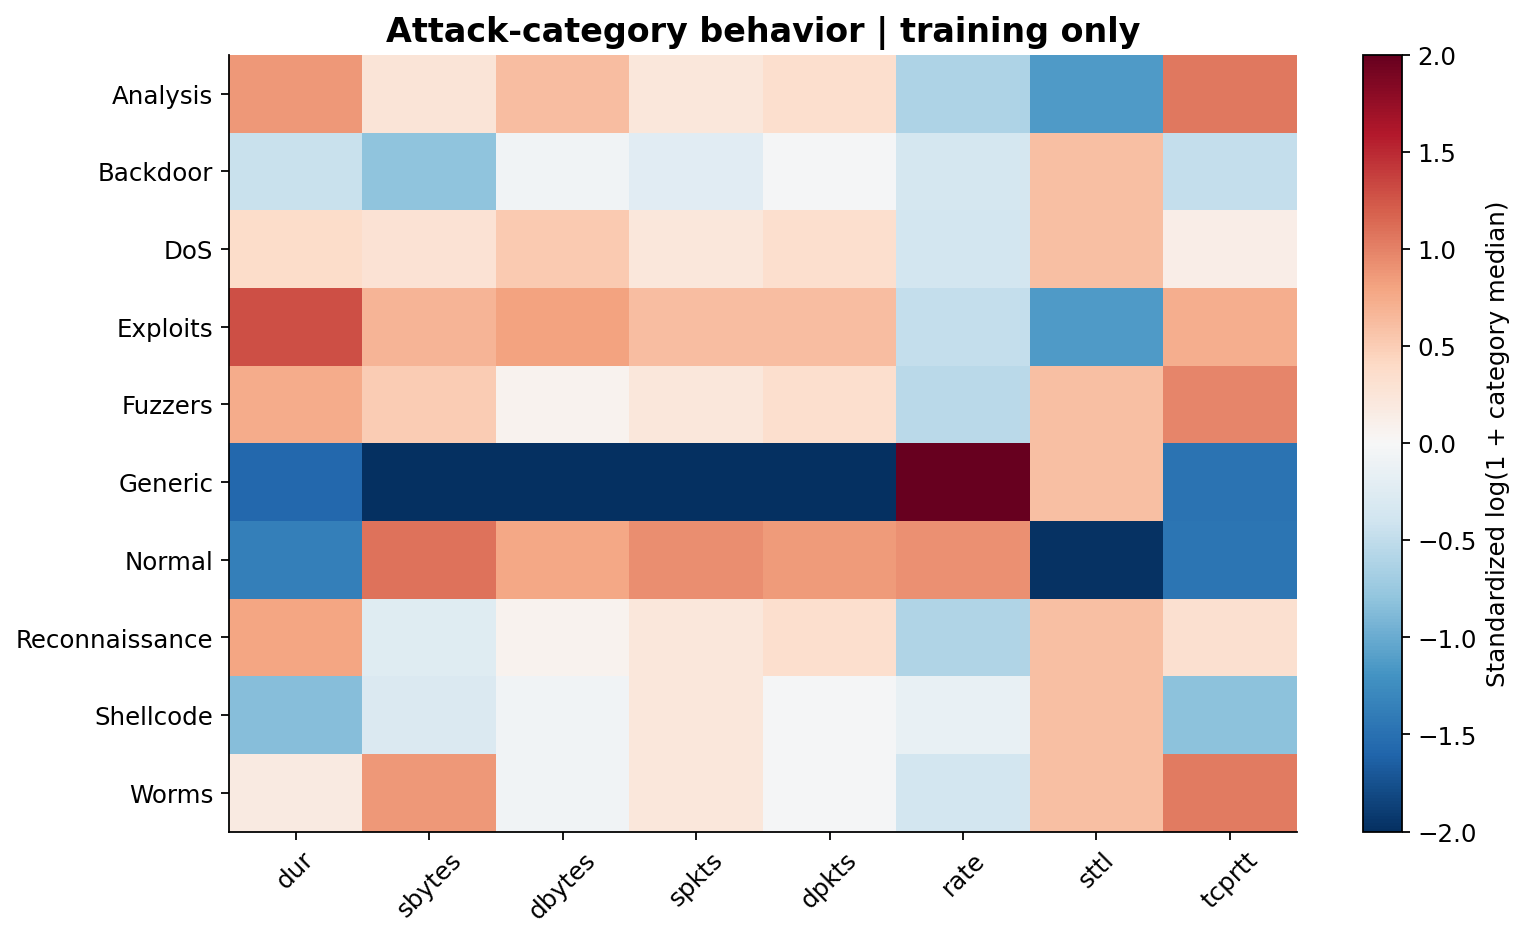

,attack_cat,dur,sbytes,dbytes,spkts,dpkts,rate,sttl,tcprtt
0,Analysis,0.723846,818.0,1158.0,10.0,8.0,24.112723,62.0,0.129755
1,Backdoor,0.284979,364.0,268.0,8.0,6.0,50.509131,254.0,0.049036
2,DoS,0.544179,846.0,962.0,10.0,8.0,46.493946,254.0,0.080909
3,Exploits,0.895677,1128.0,1728.0,12.0,10.0,35.569292,62.0,0.112129
4,Fuzzers,0.677138,994.0,354.0,10.0,8.0,29.611262,254.0,0.126088
5,Generic,0.000008,114.0,0.0,2.0,0.0,125000.000300,254.0,0.000000
6,Normal,0.046413,1540.0,1644.0,14.0,12.0,1495.271915,31.0,0.000654
7,Reconnaissance,0.692833,564.0,354.0,10.0,8.0,24.258855,254.0,0.090216
8,Shellcode,0.172199,542.0,268.0,10.0,6.0,87.109131,254.0,0.031827
9,Worms,0.475679,1302.0,268.0,10.0,6.0,47.229962,254.0,0.128870


In [4]:
figure('attack_category_behavior.png')
display(pd.read_csv(ROOT/'reports/attack_category_behavior.csv'))

Interpretation: category medians compare traffic volume, duration, TTL and TCP behavior. Color normalizes the logged medians within each feature for visual comparison; it does not indicate significance or causal attack signatures.

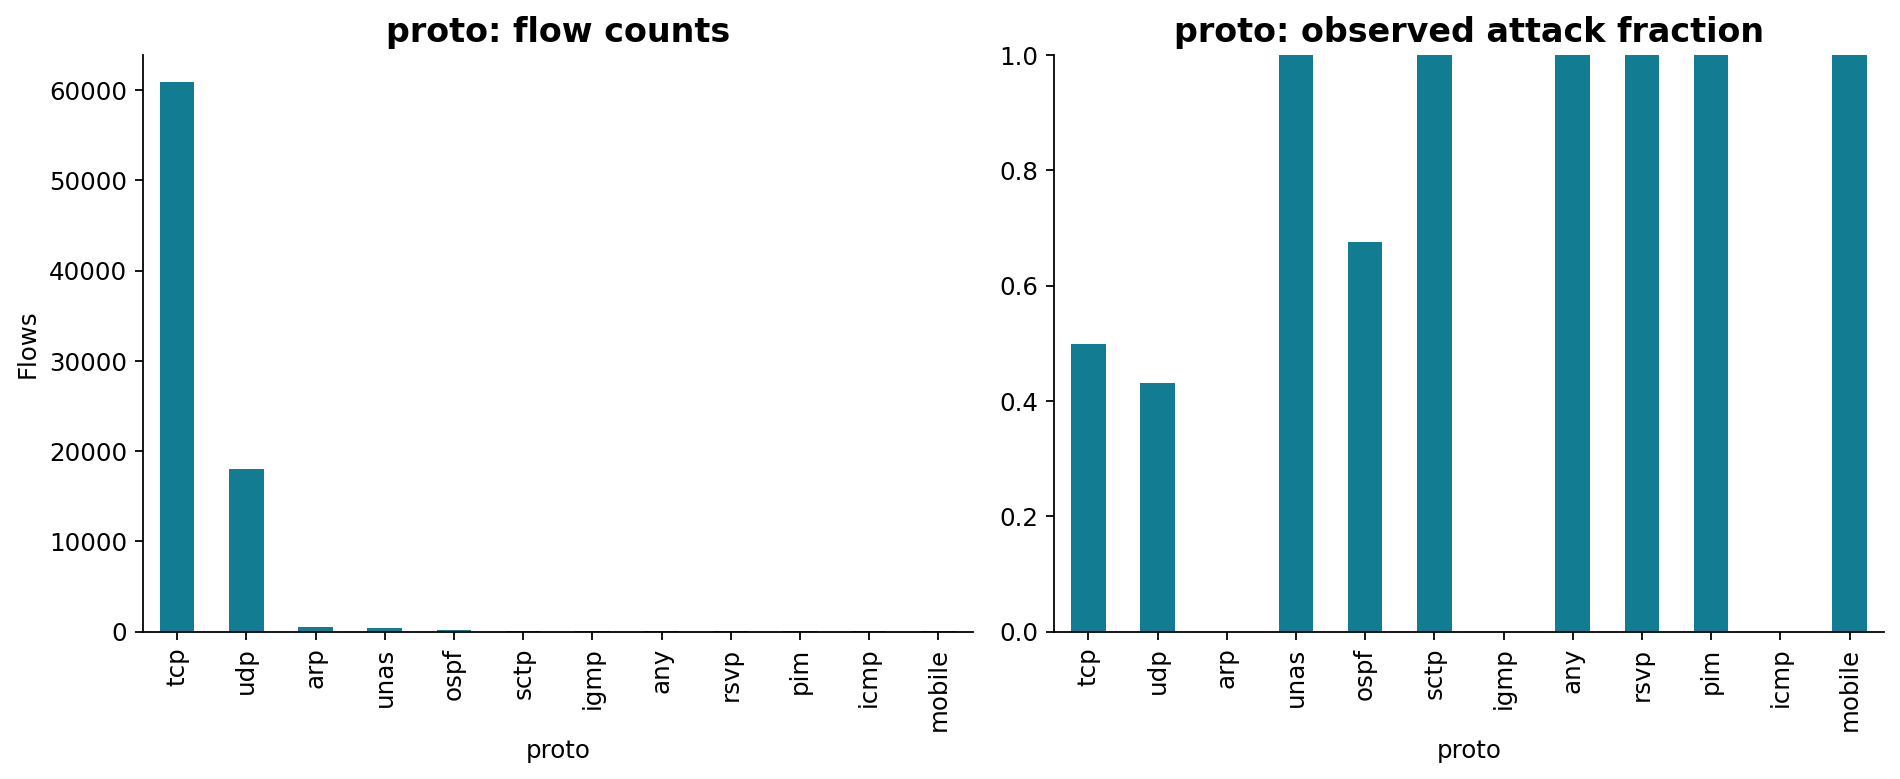

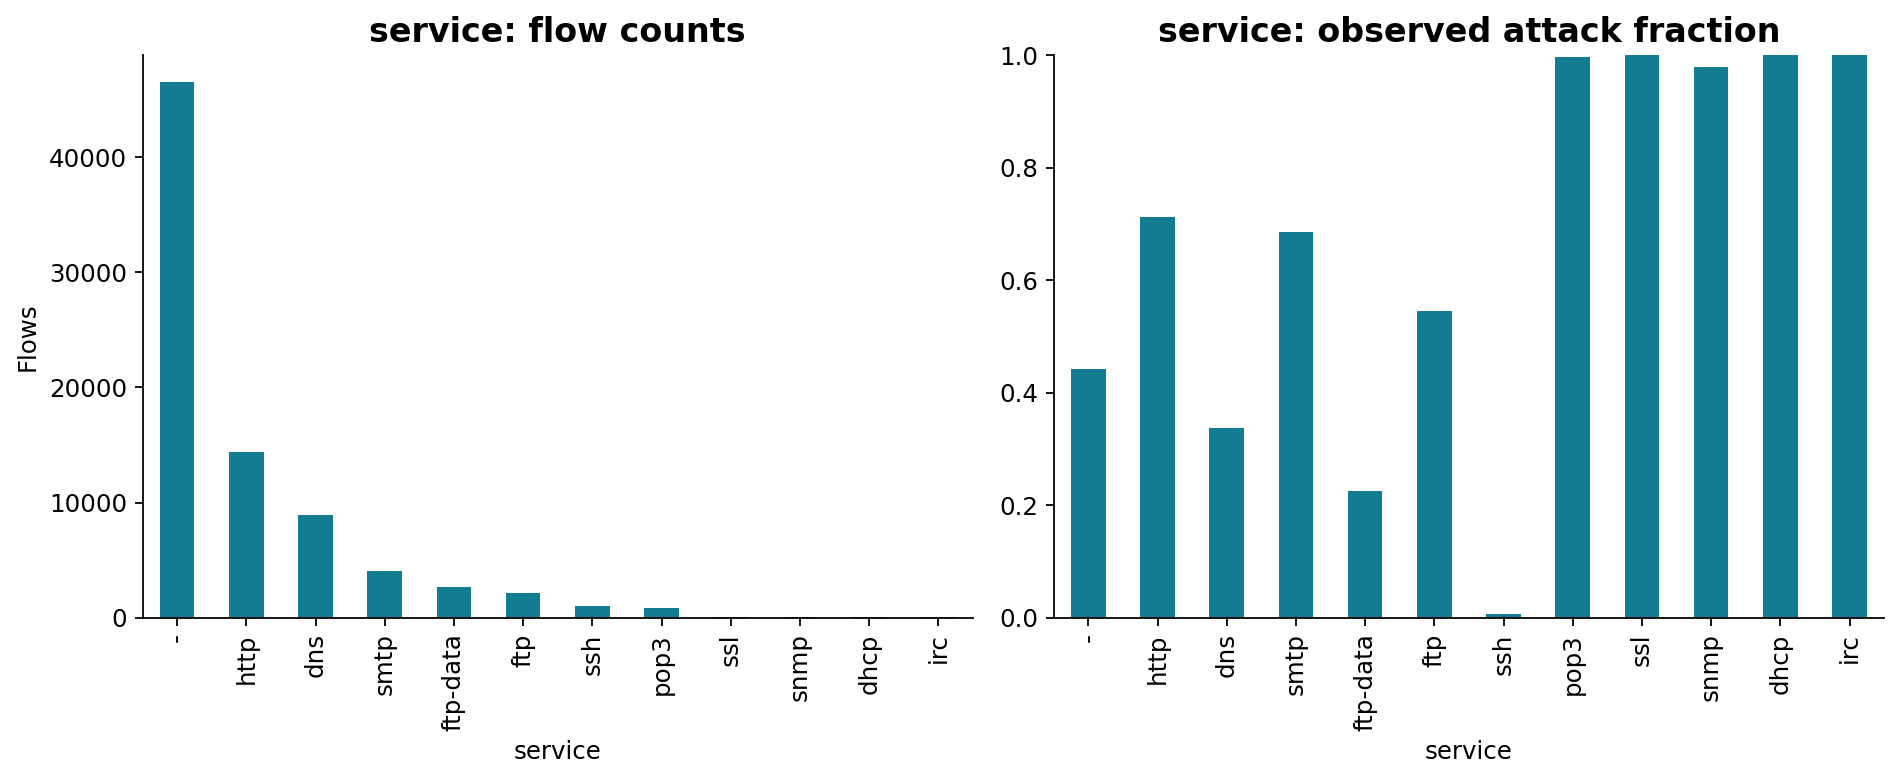

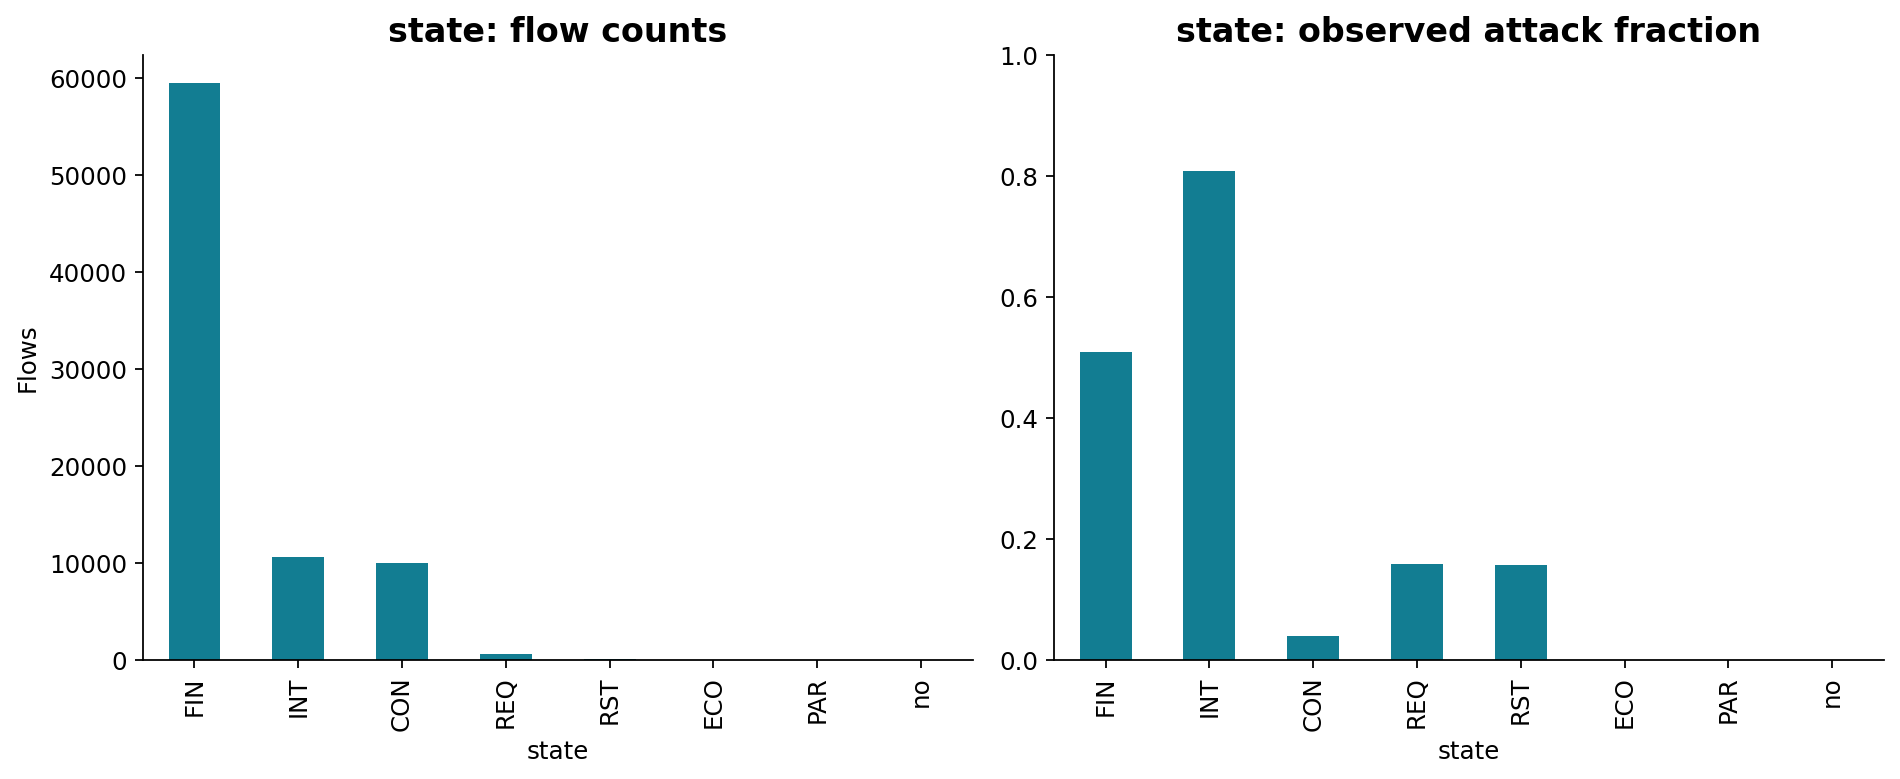

In [5]:
for name in ['proto_attack_rate.png','service_attack_rate.png','state_attack_rate.png']:
    figure(name)

Interpretation: category attack fractions are conditioned on this collection. Compare rates with support before attributing risk to any protocol or service. They are not stable security rules.

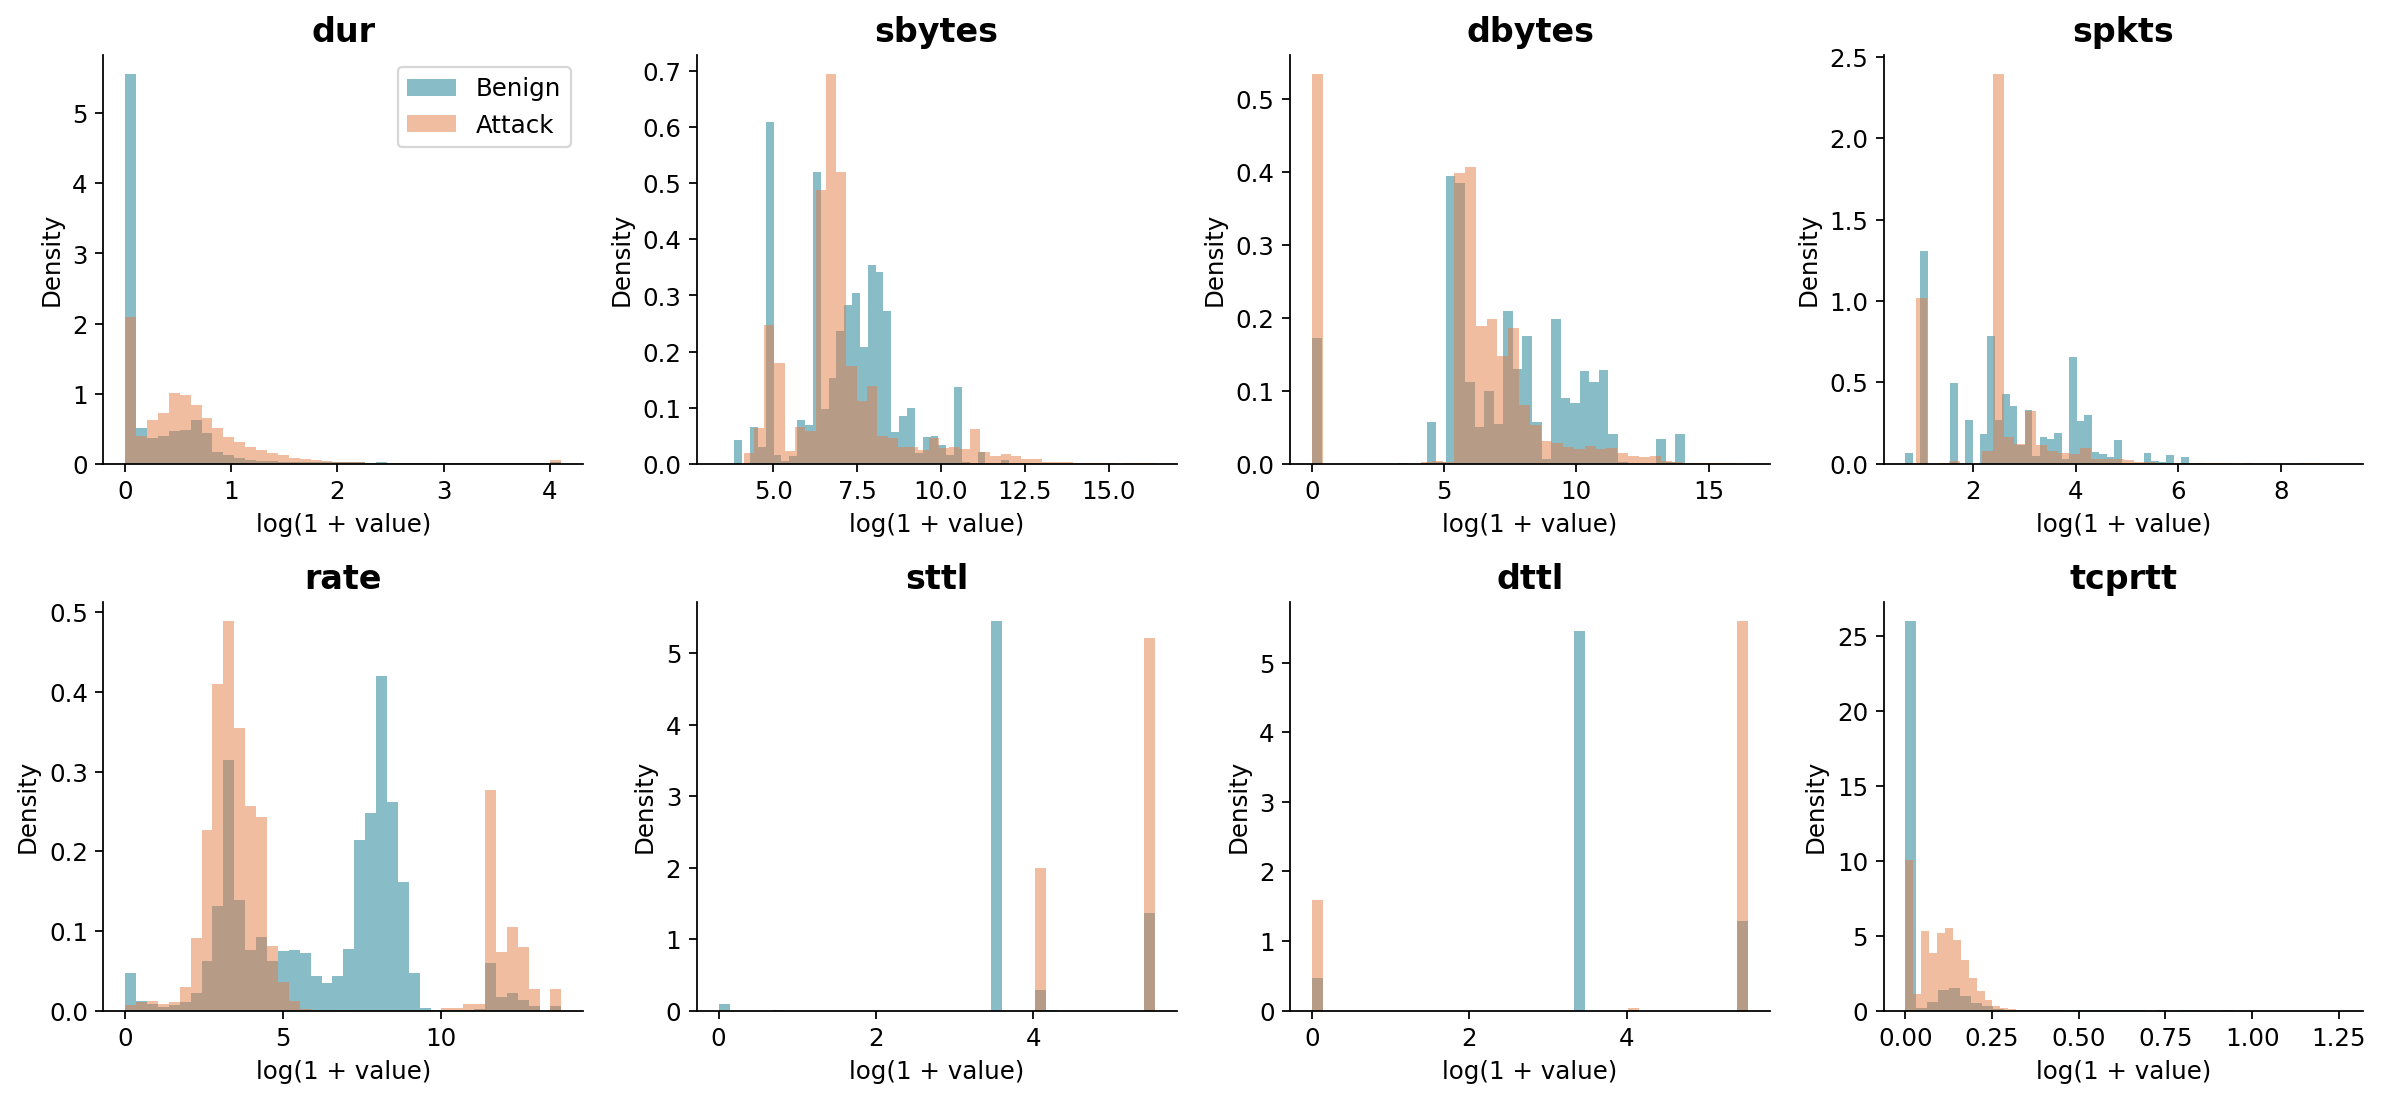

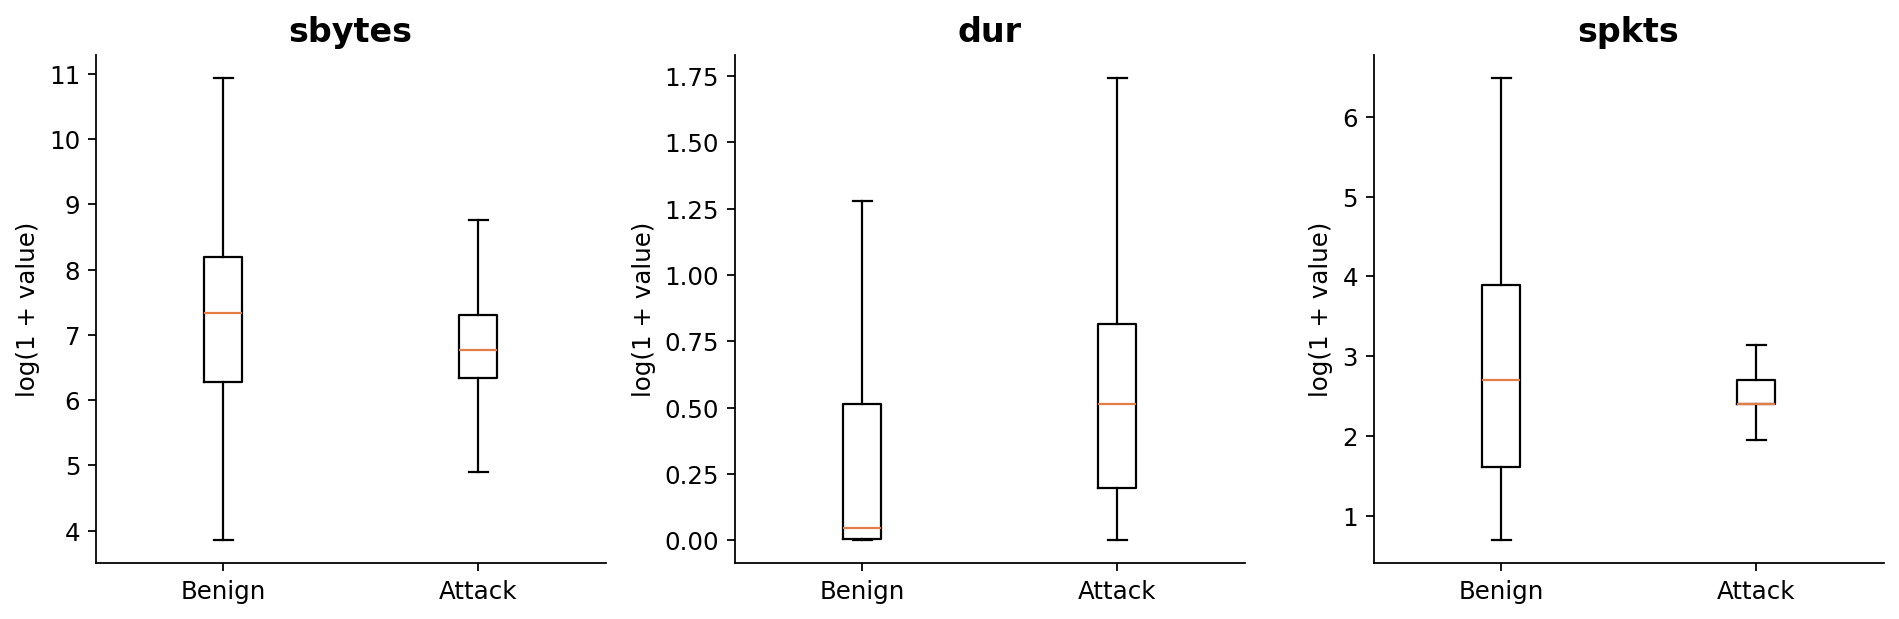

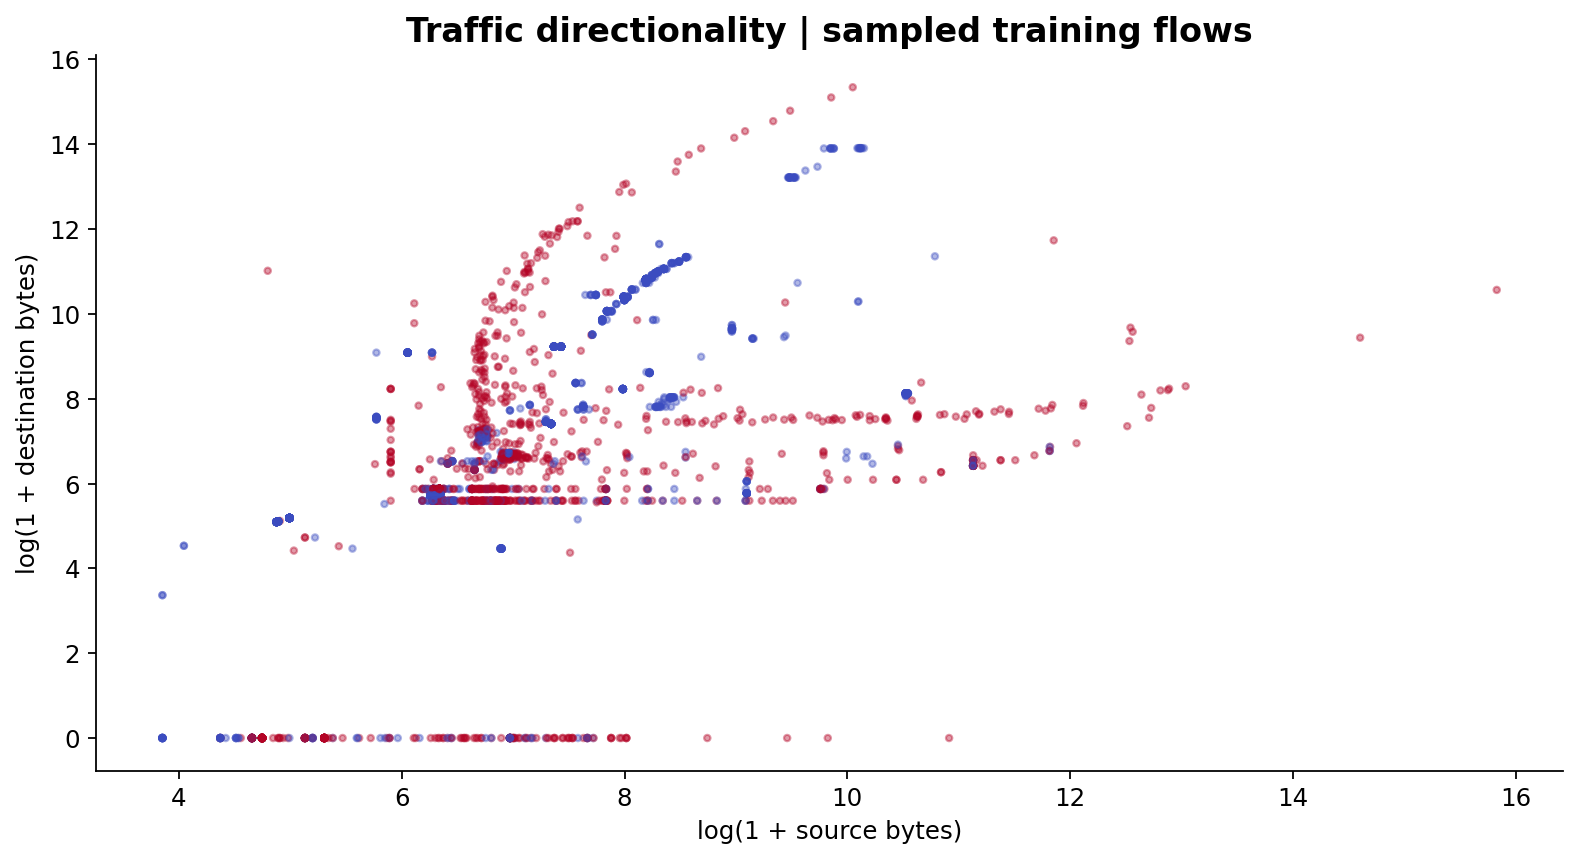

In [6]:
figure('feature_distributions.png')
figure('feature_boxplots.png')
figure('byte_relationship.png')

Interpretation: log(1+x) reveals skew and overlap in numeric features. Extremes are retained because large volumes or unusual timing can describe attack traffic. Boxplots hide individual outlier markers for readability; the outlier table retains their counts.

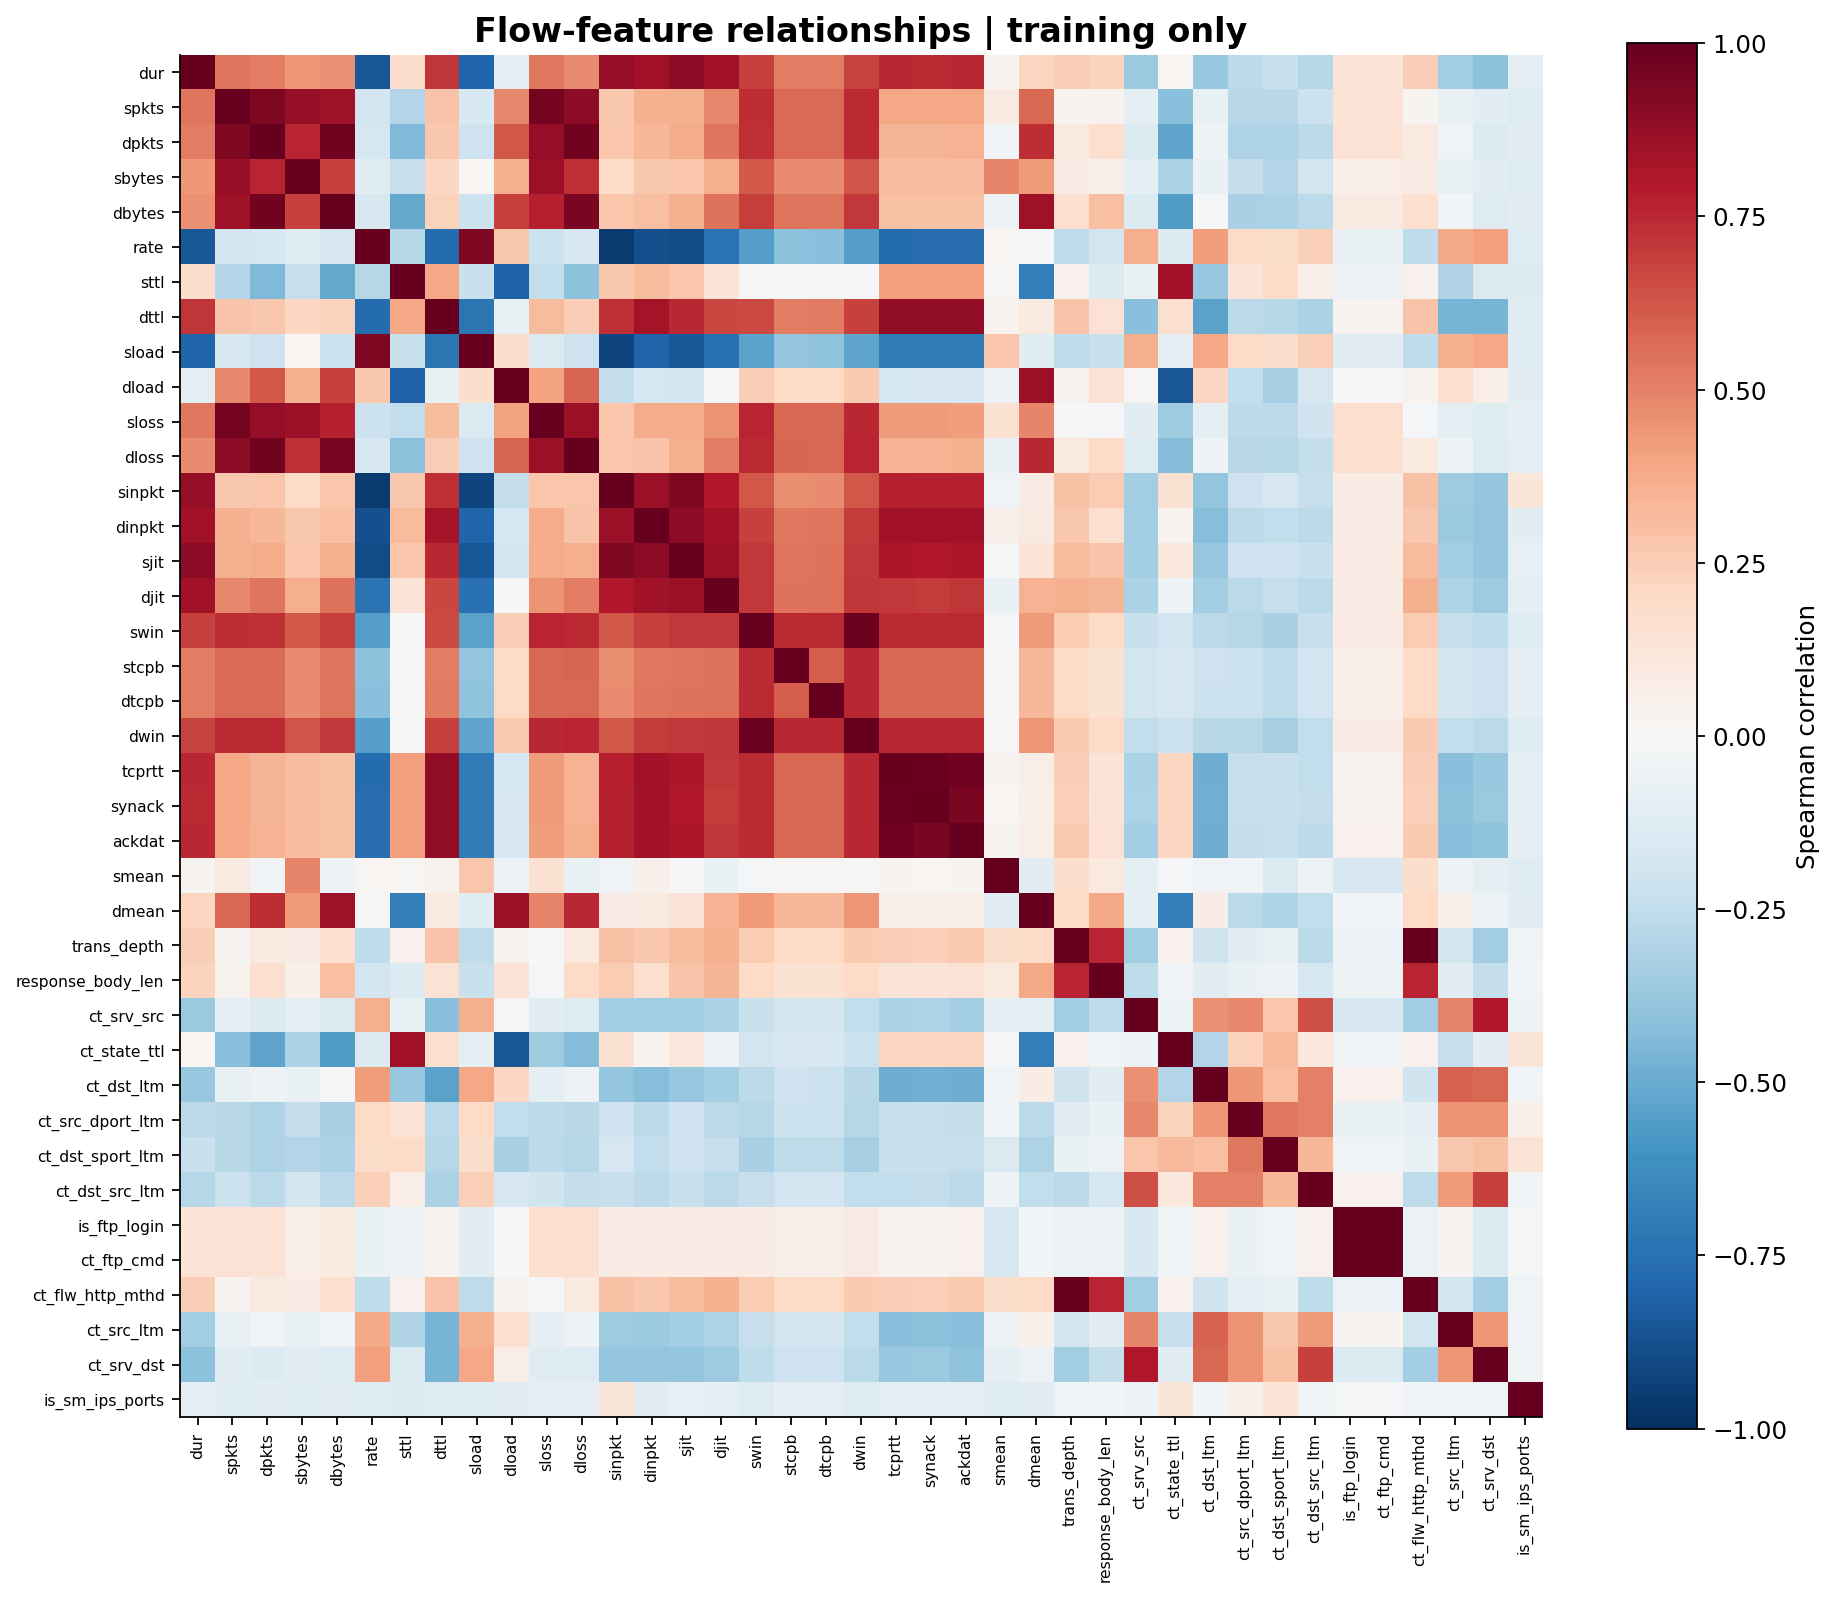

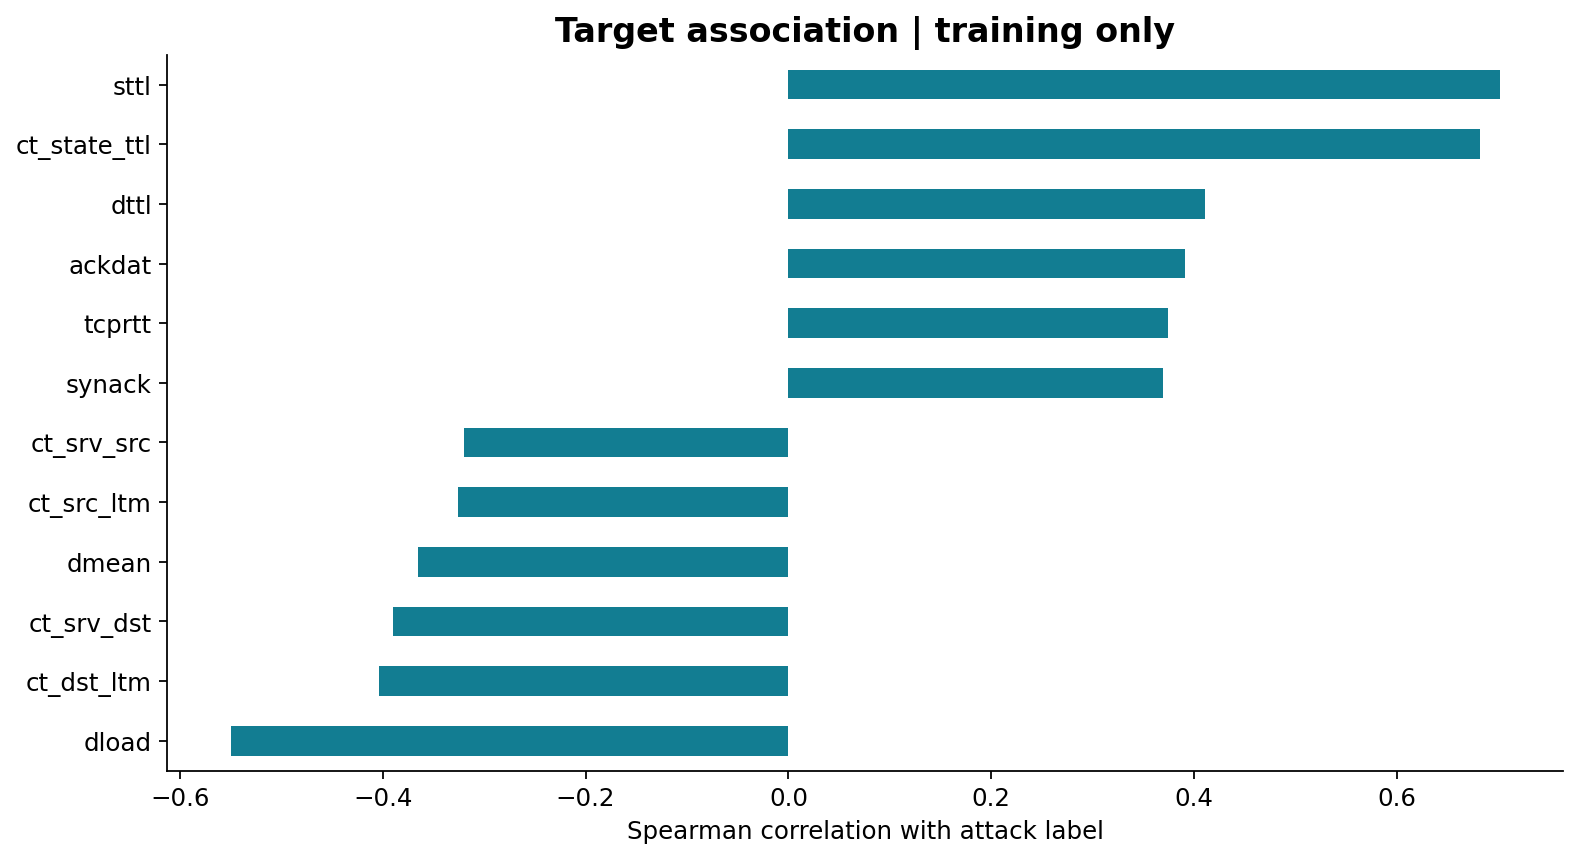

,Unnamed: 0,iqr_outlier_fraction
0,swin,0.245598
1,ct_src_dport_ltm,0.226379
2,dmean,0.200675
3,dbytes,0.199038
4,sload,0.173470
5,trans_depth,0.169415
6,ct_flw_http_mthd,0.169415
7,spkts,0.163228
8,smean,0.146910
9,rate,0.142905


In [7]:
figure('correlations.png')
figure('target_association.png')
display(pd.read_csv(ROOT/'reports/outlier_analysis.csv').head(15))

Interpretation: correlation suggests redundancy and possible environment shortcuts. It neither proves leakage nor justifies feature selection using final-test outcomes.

In [8]:
report('EDA_Feature_Engineering_Report.md')

# EDA and feature engineering

## Scope
All distribution, association and feature-design analysis uses only the development training partition. Published partition totals are used for data validation, not feature selection. Figures show observed data and tables are regenerated by executed code.

## Class balance and traffic categories
Training includes 80,648 flows after duplicate handling. Class and attack-category plots show representation; protocol, service and state charts display both counts and attack fractions. Small category attack rates are unstable and may reflect the collection setup rather than transportable rules. Class weighting is a tuning option; SMOTE is not used because interpolating mixed protocol and aggregate-count features is hard to justify.

## Numeric relationships
`feature_distributions.png` compares log(1+x) distributions of duration, source/destination bytes, packets, rate, TTL and TCP round-trip time. `byte_relationship.png` examines bidirectional volume; `correlations.png` measures Spearman relationships. Log axes aid visualization only: the fitted pipeline uses original numeric values followed by standard scaling. Highly correlated source/destination statistics and aggregate counts may divide attribution among related features.

Top training target associations (association is not causality):

| Unnamed: 0   |   spearman_with_target |
|:-------------|-----------------------:|
| sttl         |                 0.7012 |
| ct_state_ttl |                 0.6816 |
| dload        |                -0.5496 |
| dttl         |                 0.4102 |
| ct_dst_ltm   |                -0.4033 |
| ackdat       |                 0.3906 |

TTL and TCP sequence fields can encode operating-system or collection-environment characteristics. They are not label annotations, but high reliance is a transferability concern. Future evaluation should test their removal on an independent validation protocol before a new final test.

## Outliers and missing values
`outlier_analysis.csv` quantifies values outside 1.5 IQR fences. These are flags, not deletions: extreme traffic may be the attack signal. No values are removed merely for being extreme. Finite-value checks and zero-denominator handling prevent numerical failures. Numeric medians, categorical modes, scaling and rare-category encoding are fitted inside each CV training fold; the final pipeline refits on development training only. Unseen categories map to the learned infrequent bucket where available or an all-zero encoding otherwise. The source describes is_ftp_login as binary; any values outside that description must be treated as a dataset discrepancy, not silently relabeled.

## Engineered features
Total bytes and packets describe traffic volume. Bytes per packet approximates flow size structure. Source byte share and packet share measure directionality without unstable division by destination-only counts. Bytes per second relates volume to duration. All formulas and zero handling are in `data_dictionary.csv` and `src/features.py`; transformations do not inspect labels.

## Feature importance and ablation
SHAP importance is used for feature analysis; no test-driven feature selection is performed. The original-feature ablation refits the validation-selected model family with the same hyperparameters and compares at 0.50 on validation data. It is a limited conditional comparison, not a retuned competition, and does not change the frozen winner.

| features   |   precision |   recall |     f1 |   roc_auc |   pr_auc |
|:-----------|------------:|---------:|-------:|----------:|---------:|
| Original   |      0.9180 |   0.9490 | 0.9333 |    0.9861 |   0.9842 |
| Engineered |      0.9201 |   0.9486 | 0.9341 |    0.9862 |   0.9843 |
